In [1]:
from dinsystem import JaxSystemParameters, simulate
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [ ]:
key = jax.random.PRNGKey(42)
ALPHA = 0.75
DELTA = 1.0
GAMMA = (1 + (4 * ALPHA * (1 - ALPHA) + DELTA) / (1 + DELTA)) / 2 #grants, that gamma > gamma_crit
M = 60
N = 100

A = ((1 - M / N) * DELTA * GAMMA + DELTA * (1 - GAMMA) + M / N *(1 - ALPHA) / ALPHA + 1) / (DELTA * M / N * (1 - GAMMA) + DELTA * ALPHA * (1 - M / N))
B = 1 / ALPHA / DELTA / (1 - GAMMA)
L = 1 + ALPHA * (N / M - 1) / (1 - GAMMA)

print(A / B < (2 * ALPHA - 1) ** 2)

det = ((B * (2 * ALPHA - 1) ** 2 - A) / (B - A)) ** 0.5
e_p = L * (((B - A) / 2 / ALPHA / B ** 2) ** (ALPHA / (1 - ALPHA)) * 
           (((4 * ALPHA - 1) * B - (2 * ALPHA - 1) * A)/(B - A) + det) ** (ALPHA / (1 - ALPHA)) * (1 - det) /
           ((2 * ALPHA - 1) + det))
e_m = L * (((B - A) / 2 / ALPHA / B ** 2) ** (ALPHA / (1 - ALPHA)) * 
           (((4 * ALPHA - 1) * B - (2 * ALPHA - 1) * A)/(B - A) - det) ** (ALPHA / (1 - ALPHA)) * (1 + det) /
           ((2 * ALPHA - 1) - det))
e_p, e_m

True


(0.0031447113611553354, 0.007433940413091185)

In [23]:
params = [JaxSystemParameters(ALPHA, GAMMA, DELTA, N * e) for e in jnp.linspace(0.015 , 0.2, 100)]
mem = []
err = []
for param in params:
    for s_start  in [10e-6, 10e-5, 10e-4, 10e-3, 10e-2, 10e-1]:
        s0 = jnp.zeros(shape = (N,))
        s0 = s0.at[0:M].set(s_start)
        s_path, k_path = simulate(s0, param, 10000)
        if sum(s_path[-1,:] != 0) != M:
            assert 'Not M spenders at equilibrium'
        err.append(abs(k_path[-1] - k_path[-2])/k_path[-1])
        mem.append((k_path[-1] ** ALPHA + param.E / N, param.E / N))
print(f"Max error {max(err)}")

Max error 0.0059754992835223675


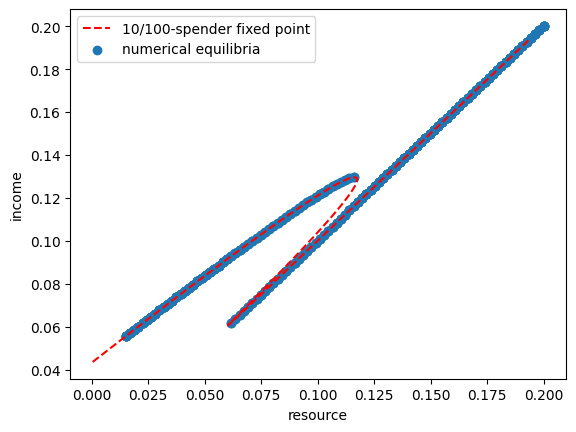

In [28]:
jmem = jnp.array(mem)


get_eq = lambda k: - L * (k ** ALPHA - A * k) / (1 - B * k ** (1 - ALPHA))
LEFT, RIGHT = min(A, B), max(A, B)
powers = jnp.linspace((-1 / (1 - ALPHA)) * jnp.log10(LEFT) - 0.001, (-1 / (1 - ALPHA)) * jnp.log10(RIGHT) + 0.1, 1000)
ks = [10 ** power for power in powers]
points = jnp.array([(k, get_eq(k)) for k in ks])
dgp = jnp.array([(k ** ALPHA + e, e) for k, e in points])

plt.xlabel('resource')
plt.ylabel('income')
plt.plot(dgp[:, 1], dgp[:, 0], color='red', label = f'{M}/{N}-spender fixed point',linestyle='dashed')
plt.scatter(jmem[:,1],jmem[:,0], label = 'numerical equilibria')
plt.legend()

In [5]:
params = [JaxSystemParameters(ALPHA, GAMMA, DELTA, e) for e in jnp.linspace(0, 0.5, 1000)]
mem = []
for param in params:
    s0 = jnp.zeros(shape = (N,))
    s0 = s0.at[0:M].set(0.0001)
    s_path, k_path = simulate(s0, param, 10000)
    mem.append(k_path[-1])

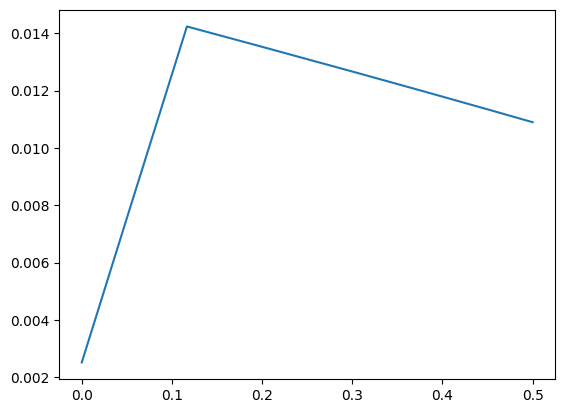

In [6]:
plt.plot([e for e in jnp.linspace(0, 0.5, 1000)],mem)

/home/olegoleg/.pyenv/versions/vc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


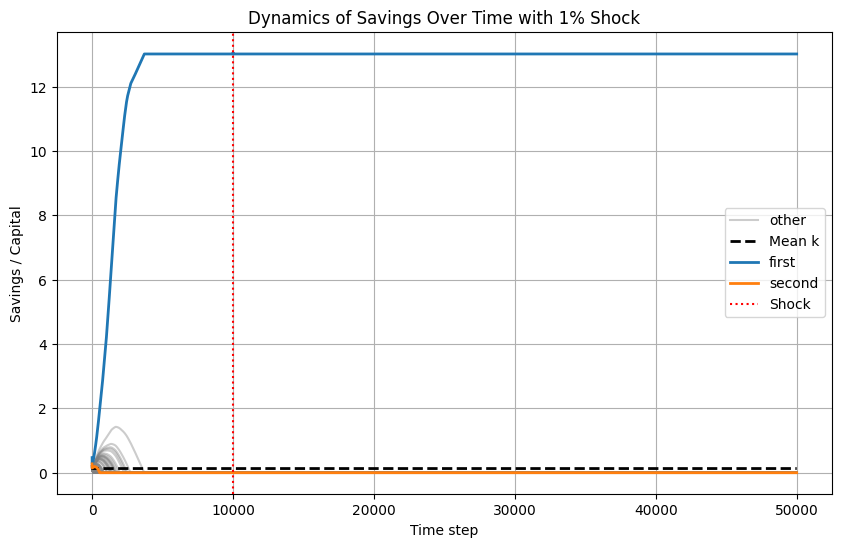

In [7]:
key = jax.random.PRNGKey(42)

N = 100          # number of agents
T1 = 10000       # steps before shock
T2 = 40000       # steps after shock

s0 = jax.random.uniform(key, shape=(N,), minval=0.5, maxval=1.5)
s0 = s0.at[0].set(2.0)

params = JaxSystemParameters(alpha=0.3, gamma=0.74, delta=4.0, E=0.0)

# -------------------------------------------------
# Phase 1: simulate T1 steps
# -------------------------------------------------
s_path_1, k_path_1 = simulate(s0, params, T1)

# -------------------------------------------------
# Shock: +x% to agent 0 and -x% to agent 1
# -------------------------------------------------
s_T1 = s_path_1[-1]
shock = 0.01 

s_T1_shocked = (
    s_T1
    .at[0].add(shock * s_T1[0])
    .at[1].add(-shock * s_T1[1])
)

# -------------------------------------------------
# Phase 2: simulate T2 steps from shocked state
# -------------------------------------------------
s_path_2, k_path_2 = simulate(s_T1_shocked, params, T2)

# -------------------------------------------------
# Concatenate trajectories
# -------------------------------------------------
s_path = jnp.concatenate([s_path_1, s_path_2], axis=0)
k_path = jnp.concatenate([k_path_1, k_path_2], axis=0)

T = T1 + T2

# -------------------------------------------------
# Plot dynamics
# -------------------------------------------------
plt.figure(figsize=(10, 6))

for i in range(2, N):
    plt.plot(
        range(T),
        s_path[:, i],
        color="gray",
        alpha=0.4,
        label="other" if i == 2 else None,
    )

plt.plot(
    range(T),
    k_path,
    "k--",
    linewidth=2,
    label="Mean k",
)

plt.plot(
    range(T),
    s_path[:, 0],
    label="first",
    linewidth=2,
)

plt.plot(
    range(T),
    s_path[:, 1],
    label="second",
    linewidth=2,
)

plt.axvline(T1, color="red", linestyle=":", label="Shock")

plt.xlabel("Time step")
plt.ylabel("Savings / Capital")
plt.title("Dynamics of Savings Over Time with 1% Shock")
plt.legend()
plt.grid(True)
plt.show()